# WADI Attack Detection

Random Forest baseline plus GDN and TGCN forecasters, evaluated on WADI_14days as the normal reference and WADI_attackdata as the labeled test set.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/wadi/dataset'

!pip install -q imbalanced-learn

import torch
print("CUDA available:", torch.cuda.is_available())

Mounted at /content/drive
CUDA available: True


## 1. Imports

In [ ]:
import time
import itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              average_precision_score, precision_recall_curve,
                              f1_score, precision_score, recall_score, accuracy_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from statsmodels.tsa.stattools import grangercausalitytests
import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
print("Device:", DEVICE)

Device: cuda


In [ ]:
import os
torch.set_num_threads(os.cpu_count())
print("CPU threads:", torch.get_num_threads())

def save_checkpoint(name, obj):
    torch.save(obj, f"{DATA_DIR}/{name}.pt")
    print(f"saved {name}")

def load_checkpoint(name):
    path = f"{DATA_DIR}/{name}.pt"
    if os.path.exists(path):
        print(f"loaded {name}")
        return torch.load(path, map_location=DEVICE)
    return None

CPU threads: 2


## 2. Load data

In [ ]:
df_normal = pd.read_csv(f"{DATA_DIR}/WADI_14days.csv", skiprows=4)
df_attack = pd.read_csv(f"{DATA_DIR}/WADI_attackdata.csv")

def build_datetime(df):
    dt = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%m/%d/%Y %I:%M:%S.%f %p')
    df = df.drop(columns=['Row', 'Date', 'Time']).copy()
    df.insert(0, 'datetime', dt)
    return df

df_normal = build_datetime(df_normal)
df_attack = build_datetime(df_attack)

print("Normal:", df_normal.shape)
print("Attack:", df_attack.shape)
print(df_normal[['datetime']].iloc[[0, -1]])
print(df_attack[['datetime']].iloc[[0, -1]])

Normal: (1209601, 128)
Attack: (172801, 128)
                   datetime
0       2017-09-25 18:00:00
1209600 2017-10-09 18:00:00
                  datetime
0      2017-10-09 18:00:00
172800 2017-10-11 18:00:00


## 3. Missing values

Four columns are fully empty across the whole normal file. The rest have only a handful of short gaps and are forward filled.

In [ ]:
nan_per_col = df_normal.isna().sum()
nan_per_col = nan_per_col[nan_per_col > 0].sort_values(ascending=False)
n_rows = len(df_normal)
fully_empty = nan_per_col[nan_per_col == n_rows]
partial = nan_per_col[nan_per_col < n_rows]

print(f"Columns with any NaNs: {len(nan_per_col)}")
print(f"Fully empty: {len(fully_empty)}")
print(f"Partially missing: {len(partial)}")
print(partial)

Columns with any NaNs: 9
Fully empty: 4
Partially missing: 5
\\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\2B_AIT_004_PV    20
\\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\1_AIT_002_PV     12
\\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\1_AIT_004_PV      6
\\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\3_AIT_002_PV      6
\\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\3_AIT_004_PV      6
dtype: int64


In [ ]:
DEAD_COLS = [
    '\\\\WIN-25J4RO10SBF\\LOG_DATA\\SUTD_WADI\\LOG_DATA\\2_LS_001_AL',
    '\\\\WIN-25J4RO10SBF\\LOG_DATA\\SUTD_WADI\\LOG_DATA\\2_LS_002_AL',
    '\\\\WIN-25J4RO10SBF\\LOG_DATA\\SUTD_WADI\\LOG_DATA\\2_P_001_STATUS',
    '\\\\WIN-25J4RO10SBF\\LOG_DATA\\SUTD_WADI\\LOG_DATA\\2_P_002_STATUS',
]

df_normal = df_normal.drop(columns=DEAD_COLS)
df_attack = df_attack.drop(columns=DEAD_COLS)
df_normal = df_normal.ffill()
df_attack = df_attack.ffill()

print("Normal NaNs remaining:", df_normal.isna().sum().sum())
print("Attack NaNs remaining:", df_attack.isna().sum().sum())

Normal NaNs remaining: 0
Attack NaNs remaining: 0


## 4. Attack labels

Windows taken from the official attack description table. Attack 9's date is corrected here, the source table lists 10/10 which overlaps attack 3 to 4 and catches zero rows, the actual date is 10/11.

In [ ]:
attack_windows = [
    ("2017-10-09 19:25:00", "2017-10-09 19:50:16"),
    ("2017-10-10 10:24:10", "2017-10-10 10:34:00"),
    ("2017-10-10 10:55:00", "2017-10-10 11:24:00"),
    ("2017-10-10 11:30:40", "2017-10-10 11:44:50"),
    ("2017-10-10 13:39:30", "2017-10-10 13:50:40"),
    ("2017-10-10 14:48:17", "2017-10-10 14:59:55"),
    ("2017-10-10 17:40:00", "2017-10-10 17:49:40"),
    ("2017-10-11 10:55:00", "2017-10-11 10:56:27"),
    ("2017-10-11 11:17:54", "2017-10-11 11:31:20"),
    ("2017-10-11 11:36:31", "2017-10-11 11:47:00"),
    ("2017-10-11 11:59:00", "2017-10-11 12:05:00"),
    ("2017-10-11 12:07:30", "2017-10-11 12:10:52"),
    ("2017-10-11 12:16:00", "2017-10-11 12:25:36"),
    ("2017-10-11 15:26:30", "2017-10-11 15:37:00"),
]
attack_windows = [(pd.Timestamp(s), pd.Timestamp(e)) for s, e in attack_windows]

def label_attack_id(dt):
    for i, (start, end) in enumerate(attack_windows, 1):
        if start <= dt <= end:
            return i
    return 0

df_attack['label'] = 0
for start, end in attack_windows:
    mask = (df_attack['datetime'] >= start) & (df_attack['datetime'] <= end)
    df_attack.loc[mask, 'label'] = 1
df_attack['attack_id'] = df_attack['datetime'].apply(label_attack_id)

print(df_attack['label'].value_counts())
print(f"Attack ratio: {df_attack['label'].mean():.3%}")

label
0    162853
1      9948
Name: count, dtype: int64
Attack ratio: 5.757%


## 5. Zero variance columns

Checked on a chronological split rather than a random one, since WADI is one second resolution and a random split would put near identical adjacent rows on both sides.

In [ ]:
def chronological_split_within_groups(df, group_col, frac=0.7):
    train_idx, test_idx = [], []
    for gid, g in df.groupby(group_col):
        g = g.sort_values('datetime')
        cut = int(len(g) * frac)
        train_idx.extend(g.index[:cut].tolist())
        test_idx.extend(g.index[cut:].tolist())
    return df.loc[train_idx].sort_index(), df.loc[test_idx].sort_index()

train_df, test_df = chronological_split_within_groups(df_attack, 'attack_id', frac=0.7)

feature_cols = [c for c in df_attack.columns if c not in ['datetime', 'label', 'attack_id']]
X_train_raw, y_train = train_df[feature_cols], train_df['label']
X_test_raw, y_test = test_df[feature_cols], test_df['label']

train_std = X_train_raw.std()
low_var_cols = train_std[train_std < 1e-6].sort_values()
print(f"Zero or near zero variance columns: {len(low_var_cols)}")
print(low_var_cols)

Zero or near zero variance columns: 27
\\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\1_LS_001_AL             0.000000e+00
\\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\1_LS_002_AL             0.000000e+00
\\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\1_P_002_STATUS          0.000000e+00
\\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\1_P_004_STATUS          0.000000e+00
\\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\2_MV_001_STATUS         0.000000e+00
\\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\2_MV_002_STATUS         0.000000e+00
\\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\2_MV_004_STATUS         0.000000e+00
\\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\2_MV_005_STATUS         0.000000e+00
\\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\2_MV_009_STATUS         0.000000e+00
\\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\2_P_004_STATUS          0.000000e+00
\\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\2_SV_101_STATUS         0.000000e+00
\\WIN-25J4RO10SBF\LOG_DATA\SUTD_WADI\LOG_DATA\2_

In [ ]:
dead_cols_v2 = low_var_cols.index.tolist()

df_attack = df_attack.drop(columns=dead_cols_v2)
df_normal = df_normal.drop(columns=dead_cols_v2)

feature_cols = [c for c in df_attack.columns if c not in ['datetime', 'label', 'attack_id']]
X_train_raw, y_train = train_df[feature_cols], train_df['label']
X_test_raw, y_test = test_df[feature_cols], test_df['label']

print(f"Dropped {len(dead_cols_v2)} columns")
print("df_attack:", df_attack.shape, "df_normal:", df_normal.shape)

Dropped 27 columns
df_attack: (172801, 99) df_normal: (1209601, 97)


## 6. Random Forest baseline

WADI's established literature results are semi-supervised forecasters trained on normal data only, RF here is a supervised baseline included to characterize how a labeled classifier performs and to check whether it generalizes across attack types.

In [ ]:
rf_scaler = StandardScaler()
X_train_scaled = rf_scaler.fit_transform(X_train_raw)
X_test_scaled = rf_scaler.transform(X_test_raw)

X_train_res, y_train_res = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train_scaled, y_train)
rf_final = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=2,
                                   max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1)
rf_final.fit(X_train_res, y_train_res)

train_probs = rf_final.predict_proba(X_train_scaled)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_train, train_probs)
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-10)
best_idx = f1s[:-1].argmax()
rf_threshold = thresholds[best_idx]

test_probs = rf_final.predict_proba(X_test_scaled)[:, 1]
test_preds = (test_probs >= rf_threshold).astype(int)

rf_results = {
    "accuracy": accuracy_score(y_test, test_preds),
    "precision": precision_score(y_test, test_preds, zero_division=0),
    "recall": recall_score(y_test, test_preds, zero_division=0),
    "f1": f1_score(y_test, test_preds, zero_division=0),
    "roc_auc": roc_auc_score(y_test, test_probs),
    "pr_auc": average_precision_score(y_test, test_probs),
}
print("Chosen threshold:", rf_threshold)
for k, v in rf_results.items():
    print(f"  {k:10s}: {v:.4f}")
print(classification_report(y_test, test_preds, digits=4))
print(confusion_matrix(y_test, test_preds))

Chosen threshold: 0.6891156057872181
  accuracy  : 0.9160
  precision : 0.3757
  recall    : 0.6873
  f1        : 0.4858
  roc_auc   : 0.8936
  pr_auc    : 0.4323
              precision    recall  f1-score   support

           0     0.9798    0.9300    0.9543     48856
           1     0.3757    0.6873    0.4858      2993

    accuracy                         0.9160     51849
   macro avg     0.6778    0.8087    0.7201     51849
weighted avg     0.9449    0.9160    0.9272     51849

[[45438  3418]
 [  936  2057]]


### RF generalization check

Blocked cross validation on the training split. Every fold contains a healthy number of attack rows, but confidence collapses on folds that hold out certain attack windows from training, this mirrors the leave-one-attack-out generalization gap found on BATADAL.

In [ ]:
kf_blocked = KFold(n_splits=3, shuffle=False)

for fold_i, (tr_idx, va_idx) in enumerate(kf_blocked.split(X_train_scaled)):
    X_tr, X_va = X_train_scaled[tr_idx], X_train_scaled[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

    X_tr_res, y_tr_res = SMOTE(random_state=RANDOM_STATE).fit_resample(X_tr, y_tr)
    rf = RandomForestClassifier(n_estimators=150, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_tr_res, y_tr_res)

    probs = rf.predict_proba(X_va)[:, 1]
    preds = (probs >= 0.5).astype(int)
    print(f"fold {fold_i}: predicted positives={preds.sum()}, actual positives={int(y_va.sum())}, "
          f"max predicted prob={probs.max():.4f}, mean prob for true attacks={probs[y_va.values==1].mean():.4f}")

fold 0: predicted positives=0, actual positives=1061, max predicted prob=0.1133, mean prob for true attacks=0.0206
fold 1: predicted positives=10348, actual positives=3184, max predicted prob=0.8200, mean prob for true attacks=0.5597
fold 2: predicted positives=0, actual positives=2710, max predicted prob=0.3733, mean prob for true attacks=0.1310


## 7. Normal and attack splits for the forecasters
Holds out the last 15% of the normal series as validation for the forecasters, since GDN/TGCN need a normal-only baseline to score deviations against, unlike RF which is trained directly on labeled attack/normal rows.

In [ ]:
val_frac = 0.15
split_idx = int(len(df_normal) * (1 - val_frac))

normal_train = df_normal.iloc[:split_idx]
normal_val = df_normal.iloc[split_idx:]

gnn_feature_cols = [c for c in df_normal.columns if c != 'datetime']
n_nodes = len(gnn_feature_cols)

gnn_scaler = StandardScaler()
normal_train_scaled = gnn_scaler.fit_transform(normal_train[gnn_feature_cols])
normal_val_scaled = gnn_scaler.transform(normal_val[gnn_feature_cols])
attack_scaled = gnn_scaler.transform(df_attack[gnn_feature_cols])

print("normal_train_scaled:", normal_train_scaled.shape)
print("normal_val_scaled:", normal_val_scaled.shape)
print("attack_scaled:", attack_scaled.shape)
print("n_nodes:", n_nodes)

normal_train_scaled: (1028160, 96)
normal_val_scaled: (181441, 96)
attack_scaled: (172801, 96)
n_nodes: 96


## 8. Sensor graphs

Both graphs are fit on normal data only. Correlation is undefined for a handful of sensors that never move across all 14 days, these fall back to zero weight during graph construction.

In [ ]:
def build_correlation_edge_index(X, topk=10):
    n = X.shape[1]
    corr = np.nan_to_num(np.corrcoef(X, rowvar=False), nan=0.0)
    np.fill_diagonal(corr, 0.0)
    abs_corr = np.abs(corr)
    src, dst = [], []
    for i in range(n):
        for j in np.argsort(-abs_corr[i])[:topk]:
            src.append(j); dst.append(i)
    return np.array([src, dst], dtype=np.int64)

X_normal_all = df_normal[gnn_feature_cols].values
corr_edge_index_np = build_correlation_edge_index(X_normal_all, topk=10)
print(f"Correlation graph: {n_nodes} nodes, {corr_edge_index_np.shape[1]} directed edges")

Correlation graph: 96 nodes, 960 directed edges


/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:
np.save(f"{DATA_DIR}/corr_edge_index.npy", corr_edge_index_np)

In [ ]:
GRANGER_MAXLAG = 3
GRANGER_ALPHA = 0.05
GRANGER_TOPK = 10
GRANGER_SAMPLE_ROWS = 20000

X_granger_sample = X_normal_all[:GRANGER_SAMPLE_ROWS]

def build_granger_edge_index(X_normal, maxlag=GRANGER_MAXLAG, alpha=GRANGER_ALPHA, topk=GRANGER_TOPK):
    n = X_normal.shape[1]
    pvals = np.full((n, n), np.nan)
    n_failed = 0
    total_pairs = n * (n - 1)
    t0 = time.time()

    for count, (i, j) in enumerate(itertools.permutations(range(n), 2)):
        try:
            res = grangercausalitytests(X_normal[:, [i, j]], maxlag=maxlag, verbose=False)
            pvals[i, j] = min(res[k][0]["ssr_ftest"][1] for k in range(1, maxlag + 1))
        except Exception:
            n_failed += 1

        if (count + 1) % 1000 == 0:
            elapsed = time.time() - t0
            rate = (count + 1) / elapsed
            remaining = (total_pairs - count - 1) / rate
            print(f"  {count+1}/{total_pairs} pairs, {elapsed:.0f}s elapsed, ~{remaining:.0f}s remaining", flush=True)

    corr = np.nan_to_num(np.corrcoef(X_normal, rowvar=False), nan=0.0)
    np.fill_diagonal(corr, 0.0)
    abs_corr = np.abs(corr)

    src, dst, n_fallback = [], [], 0
    for i in range(n):
        row = pvals[:, i].copy()
        row[i] = np.nan
        significant = np.where(row < alpha)[0]
        if len(significant) == 0:
            n_fallback += 1
            chosen = np.argsort(-abs_corr[i])[:topk]
        else:
            chosen = significant[np.argsort(row[significant])][:topk]
        for j in chosen:
            src.append(j); dst.append(i)

    print(f"Granger tests: {total_pairs} pairs, {n_failed} undefined")
    print(f"Correlation fallback nodes: {n_fallback}/{n}")
    return np.array([src, dst], dtype=np.int64), pvals

granger_path = f"{DATA_DIR}/granger_edge_index.npy"
if os.path.exists(granger_path):
    granger_edge_index_np = np.load(granger_path)
    print(f"loaded Granger graph: {n_nodes} nodes, {granger_edge_index_np.shape[1]} directed edges")
else:
    granger_edge_index_np, granger_pvals = build_granger_edge_index(X_granger_sample)
    np.save(granger_path, granger_edge_index_np)
    print(f"Granger graph: {n_nodes} nodes, {granger_edge_index_np.shape[1]} directed edges")

loaded Granger graph: 96 nodes, 929 directed edges


## 9. Windowing

Window size of 15 seconds balances giving the recurrent layer real temporal context against preserving post warmup coverage inside the shortest attack, which is only 88 rows. Training windows are subsampled since a GRU forward pass on CPU does not need all one million windows to learn normal behaviour.

In [ ]:
WINDOW_SIZE = 15
EMBED_DIM = 32
GRU_HIDDEN = 64
BATCH_SIZE = 256
TRAIN_SUBSAMPLE = 1000000

class SlidingWindowDataset(Dataset):
    def __init__(self, data, window_size):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.window_size = window_size
    def __len__(self):
        return len(self.data) - self.window_size
    def __getitem__(self, idx):
        x = self.data[idx: idx + self.window_size]
        y = self.data[idx + self.window_size]
        return x, y

train_ds = SlidingWindowDataset(normal_train_scaled, WINDOW_SIZE)
val_ds = SlidingWindowDataset(normal_val_scaled, WINDOW_SIZE)
test_ds = SlidingWindowDataset(attack_scaled, WINDOW_SIZE)

subsample_idx = np.linspace(0, len(train_ds) - 1, TRAIN_SUBSAMPLE, dtype=int)
train_ds_sub = Subset(train_ds, subsample_idx)

train_loader = DataLoader(train_ds_sub, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Windows, train subsampled/val/test:", len(train_ds_sub), len(val_ds), len(test_ds))

Windows, train subsampled/val/test: 1000000 181426 172786


## 10. Models

GDN and TGCN both take a fixed edge structure as input rather than learning their own graph, so the correlation graph and the Granger graph produce genuinely different models.

In [ ]:
class GraphAttentionLayer(nn.Module):
    def __init__(self, in_dim, out_dim, edge_index, n_nodes):
        super().__init__()
        self.edge_index, self.n_nodes = edge_index, n_nodes
        self.lin = nn.Linear(in_dim, out_dim)
        self.attn_src = nn.Linear(out_dim, 1, bias=False)
        self.attn_dst = nn.Linear(out_dim, 1, bias=False)

    def forward(self, x):
        h = self.lin(x)
        src, dst = self.edge_index[0], self.edge_index[1]
        e = F.leaky_relu(self.attn_src(h).squeeze(-1)[:, src] + self.attn_dst(h).squeeze(-1)[:, dst])
        e_max = e.max(dim=1, keepdim=True)[0].detach()
        e_exp = torch.exp(e - e_max)
        denom = torch.zeros(x.size(0), self.n_nodes, device=x.device)
        denom.scatter_add_(1, dst.unsqueeze(0).expand(x.size(0), -1), e_exp)
        alpha = e_exp / denom.clamp_min(1e-8)[:, dst]
        out = torch.zeros(x.size(0), self.n_nodes, h.size(-1), device=x.device)
        weighted = h[:, src] * alpha.unsqueeze(-1)
        out.scatter_add_(1, dst.unsqueeze(0).unsqueeze(-1).expand(x.size(0), -1, h.size(-1)), weighted)
        return F.relu(out)


class GDN(nn.Module):
    def __init__(self, n_nodes, edge_index, hidden_dim=16, gru_hidden=64):
        super().__init__()
        self.n_nodes = n_nodes
        self.gat = GraphAttentionLayer(1, hidden_dim, edge_index, n_nodes)
        self.gru = nn.GRU(input_size=n_nodes * hidden_dim, hidden_size=gru_hidden, batch_first=True)
        self.head = nn.Linear(gru_hidden, n_nodes)

    def forward(self, window):
        B, T, N = window.shape
        x = window.reshape(B * T, N, 1)
        h = self.gat(x).reshape(B, T, -1)
        gru_out, _ = self.gru(h)
        return self.head(gru_out[:, -1, :])


def build_normalized_adjacency(edge_index_np, n_nodes, add_self_loops=True):
    A = np.zeros((n_nodes, n_nodes), dtype=np.float32)
    A[edge_index_np[1], edge_index_np[0]] = 1.0
    if add_self_loops:
        A += np.eye(n_nodes, dtype=np.float32)
    deg = A.sum(axis=1)
    deg_inv_sqrt = np.power(deg, -0.5, where=deg > 0)
    deg_inv_sqrt[deg == 0] = 0.0
    D_inv_sqrt = np.diag(deg_inv_sqrt)
    return torch.from_numpy(D_inv_sqrt @ A @ D_inv_sqrt).to(DEVICE)


class TGCN(nn.Module):
    def __init__(self, n_nodes, adj_norm, hidden_dim=16, gru_hidden=64):
        super().__init__()
        self.n_nodes = n_nodes
        self.adj_norm = adj_norm
        self.gcn_lin = nn.Linear(1, hidden_dim)
        self.gru = nn.GRU(input_size=n_nodes * hidden_dim, hidden_size=gru_hidden, batch_first=True)
        self.head = nn.Linear(gru_hidden, n_nodes)

    def forward(self, window):
        B, T, N = window.shape
        x = window.reshape(B * T, N, 1)
        h = self.gcn_lin(x)
        h = torch.einsum("ij,bjd->bid", self.adj_norm, h)
        h = F.relu(h).reshape(B, T, -1)
        gru_out, _ = self.gru(h)
        return self.head(gru_out[:, -1, :])


if 'corr_edge_index_np' not in dir():
    corr_edge_index_np = np.load(f"{DATA_DIR}/corr_edge_index.npy")
if 'granger_edge_index_np' not in dir():
    granger_edge_index_np = np.load(f"{DATA_DIR}/granger_edge_index.npy")

corr_edge_index = torch.from_numpy(corr_edge_index_np).to(DEVICE)
granger_edge_index = torch.from_numpy(granger_edge_index_np).to(DEVICE)
adj_norm_corr = build_normalized_adjacency(corr_edge_index_np, n_nodes)
adj_norm_granger = build_normalized_adjacency(granger_edge_index_np, n_nodes)

print("Model classes and graph tensors ready")

Model classes and graph tensors ready


## 11. Training and scoring

Anomaly scoring converts each sensor's forecast error to a percentile rank against its own validation distribution, then averages the top five sensors at each timestep. This avoids letting a single sensor with a different error scale dominate the score, and avoids the ties that a hard clip produces.

One sensor, 2B_AIT_002_PV, is excluded from scoring entirely. Its forecast error steps from near zero to roughly two hundred thousand times its normal scale partway through the attack file and stays there regardless of attack labels, a regime shift unrelated to any attack, confirmed separately below.

In [ ]:
EXCLUDED_SENSORS = ['\\\\WIN-25J4RO10SBF\\LOG_DATA\\SUTD_WADI\\LOG_DATA\\2B_AIT_002_PV']
excluded_idx = [gnn_feature_cols.index(s) for s in EXCLUDED_SENSORS]
keep_mask = torch.ones(n_nodes, dtype=torch.bool)
keep_mask[excluded_idx] = False

DRIFT_CUTOFF = 78000

def train_forecaster(model, train_loader, val_loader, epochs=25, patience=5, lr=3e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=1, factor=0.5)
    criterion = nn.MSELoss()
    best_val_loss, best_state, no_improve = float("inf"), None, 0

    for epoch in range(epochs):
        model.train()
        t0 = time.time()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_losses.append(F.mse_loss(model(xb), yb).item())
        val_loss = np.mean(val_losses)
        train_loss = np.mean(train_losses)
        scheduler.step(val_loss)
        print(f"  epoch {epoch+1}/{epochs} | train {train_loss:.5f} | val {val_loss:.5f} | "
              f"lr {optimizer.param_groups[0]['lr']:.2e} | {time.time()-t0:.1f}s", flush=True)

        if val_loss < best_val_loss:
            best_val_loss, best_state, no_improve = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  early stopping at epoch {epoch+1}, best val loss {best_val_loss:.5f}")
                break

    model.load_state_dict(best_state)
    return model


def compute_per_sensor_errors(model, loader):
    model.eval()
    errs = []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            errs.append((pred - yb).abs().cpu())
    return torch.cat(errs, dim=0)


def gdn_style_anomaly_scores(val_errors, query_errors, k=5, keep_mask=keep_mask):
    val_errors = val_errors[:, keep_mask]
    query_errors = query_errors[:, keep_mask]
    n_val = val_errors.shape[0]
    val_sorted, _ = torch.sort(val_errors, dim=0)

    def to_percentile(errors):
        ranks = torch.searchsorted(val_sorted.T.contiguous(), errors.T.contiguous()).T.float()
        return ranks / n_val

    val_pct = to_percentile(val_errors)
    query_pct = to_percentile(query_errors)
    val_scores = val_pct.topk(k, dim=1).values.mean(dim=1)
    query_scores = query_pct.topk(k, dim=1).values.mean(dim=1)
    return val_scores, query_scores


def evaluate_model(model, val_loader, test_loader, y_true_full, window_size, label="", drift_cutoff=DRIFT_CUTOFF):
    val_errors = compute_per_sensor_errors(model, val_loader)
    test_errors = compute_per_sensor_errors(model, test_loader)
    val_scores, test_scores = gdn_style_anomaly_scores(val_errors, test_errors)

    threshold = np.percentile(val_scores.numpy(), 99.5)
    test_scores_np = test_scores.numpy()
    y_true = y_true_full[window_size:]

    if drift_cutoff is not None:
        test_scores_np = test_scores_np[:drift_cutoff]
        y_true = y_true[:drift_cutoff]

    preds = (test_scores_np >= threshold).astype(int)

    results = {
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_true, test_scores_np) if y_true.sum() > 0 else float("nan"),
        "pr_auc": average_precision_score(y_true, test_scores_np) if y_true.sum() > 0 else float("nan"),
    }
    print(f"[{label}] threshold={threshold:.4f}")
    for k, v in results.items():
        print(f"  {k:10s}: {v:.4f}")
    print(classification_report(y_true, preds, digits=4))
    return results, test_scores_np, preds, val_errors, test_errors

## 12. GDN, correlation graph

In [ ]:
gdn_corr_model = GDN(n_nodes, corr_edge_index, hidden_dim=16, gru_hidden=64).to(DEVICE)

model_path = f"{DATA_DIR}/gdn_corr_model.pt"
if os.path.exists(model_path):
    gdn_corr_model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    print("loaded existing gdn_corr model, skipping training")
else:
    gdn_corr_model = train_forecaster(gdn_corr_model, train_loader, val_loader, epochs=25, patience=5)
    torch.save(gdn_corr_model.state_dict(), model_path)

gdn_corr_results, gdn_corr_scores, gdn_corr_preds, gdn_corr_val_errors, gdn_corr_test_errors = evaluate_model(
    gdn_corr_model, val_loader, test_loader, df_attack['label'].values, WINDOW_SIZE, label="GDN + correlation"
)

torch.save({"val_errors": gdn_corr_val_errors, "test_errors": gdn_corr_test_errors}, f"{DATA_DIR}/gdn_corr_errors.pt")

loaded existing gdn_corr model, skipping training
[GDN + correlation] threshold=0.9994
  accuracy  : 0.9440
  precision : 0.7546
  recall    : 0.4150
  f1        : 0.5355
  roc_auc   : 0.7639
  pr_auc    : 0.5251
              precision    recall  f1-score   support

           0     0.9524    0.9886    0.9702     71930
           1     0.7546    0.4150    0.5355      6070

    accuracy                         0.9440     78000
   macro avg     0.8535    0.7018    0.7528     78000
weighted avg     0.9370    0.9440    0.9364     78000



### Drift diagnosis

The attack file and the fourteen day file were collected on different days with the testbed reset in between. A number of sensors drift away from their validation-time behaviour partway through the attack file, well before the final attack window ends. The plot below marks the number of sensors exceeding their own validation-time maximum error at each timestep, this rises and stays elevated from a fixed point onward regardless of attack labels, confirming a standing condition rather than attack-driven spikes. The cutoff at 78000 rows marks where this shift begins and is excluded from the primary evaluation above.

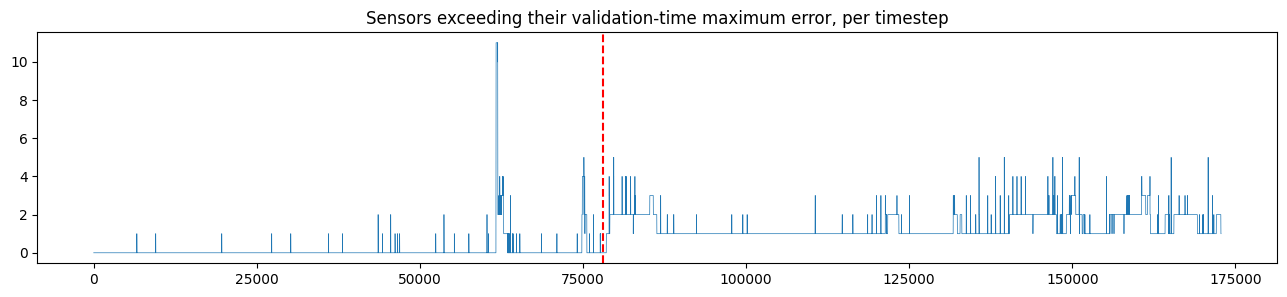

Drift cutoff corresponds to: 2017-10-10 15:40:00


In [ ]:
val_median = gdn_corr_val_errors.median(dim=0).values
val_mad = (gdn_corr_val_errors - val_median).abs().median(dim=0).values.clamp_min(1e-2)
val_max_ratio = (gdn_corr_val_errors - val_median).abs().div(val_mad).max(dim=0).values

test_norm_check = (gdn_corr_test_errors - val_median) / val_mad
above_max_count = (test_norm_check > val_max_ratio).float().sum(dim=1)

plt.figure(figsize=(16, 3))
plt.plot(above_max_count.numpy(), linewidth=0.5)
plt.axvline(DRIFT_CUTOFF, color='red', linestyle='--')
plt.title('Sensors exceeding their validation-time maximum error, per timestep')
plt.show()

drift_point_dt = df_attack.iloc[DRIFT_CUTOFF]['datetime']
print("Drift cutoff corresponds to:", drift_point_dt)

## 13. GDN, Granger graph

In [ ]:
gdn_granger_model = GDN(n_nodes, granger_edge_index, hidden_dim=16, gru_hidden=64).to(DEVICE)

model_path = f"{DATA_DIR}/gdn_granger_model.pt"
if os.path.exists(model_path):
    gdn_granger_model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    print("loaded existing gdn_granger model, skipping training")
else:
    gdn_granger_model = train_forecaster(gdn_granger_model, train_loader, val_loader, epochs=25, patience=5)
    torch.save(gdn_granger_model.state_dict(), model_path)

gdn_granger_results, gdn_granger_scores, gdn_granger_preds, gdn_granger_val_errors, gdn_granger_test_errors = evaluate_model(
    gdn_granger_model, val_loader, test_loader, df_attack['label'].values, WINDOW_SIZE, label="GDN + Granger"
)

torch.save({"val_errors": gdn_granger_val_errors, "test_errors": gdn_granger_test_errors}, f"{DATA_DIR}/gdn_granger_errors.pt")

loaded existing gdn_granger model, skipping training
[GDN + Granger] threshold=0.9993
  accuracy  : 0.9449
  precision : 0.7657
  recall    : 0.4199
  f1        : 0.5424
  roc_auc   : 0.7729
  pr_auc    : 0.5557
              precision    recall  f1-score   support

           0     0.9528    0.9892    0.9707     71930
           1     0.7657    0.4199    0.5424      6070

    accuracy                         0.9449     78000
   macro avg     0.8593    0.7045    0.7565     78000
weighted avg     0.9383    0.9449    0.9373     78000



## 14. TGCN, correlation graph

In [ ]:
tgcn_corr_model = TGCN(n_nodes, adj_norm_corr, hidden_dim=16, gru_hidden=64).to(DEVICE)

model_path = f"{DATA_DIR}/tgcn_corr_model.pt"
if os.path.exists(model_path):
    tgcn_corr_model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    print("loaded existing tgcn_corr model, skipping training")
else:
    tgcn_corr_model = train_forecaster(tgcn_corr_model, train_loader, val_loader, epochs=25, patience=5)
    torch.save(tgcn_corr_model.state_dict(), model_path)

tgcn_corr_results, tgcn_corr_scores, tgcn_corr_preds, tgcn_corr_val_errors, tgcn_corr_test_errors = evaluate_model(
    tgcn_corr_model, val_loader, test_loader, df_attack['label'].values, WINDOW_SIZE, label="TGCN + correlation"
)

torch.save({"val_errors": tgcn_corr_val_errors, "test_errors": tgcn_corr_test_errors}, f"{DATA_DIR}/tgcn_corr_errors.pt")

loaded existing tgcn_corr model, skipping training
[TGCN + correlation] threshold=0.9994
  accuracy  : 0.9434
  precision : 0.7415
  recall    : 0.4181
  f1        : 0.5347
  roc_auc   : 0.7940
  pr_auc    : 0.5583
              precision    recall  f1-score   support

           0     0.9526    0.9877    0.9699     71930
           1     0.7415    0.4181    0.5347      6070

    accuracy                         0.9434     78000
   macro avg     0.8470    0.7029    0.7523     78000
weighted avg     0.9362    0.9434    0.9360     78000



## 15. TGCN, Granger graph

In [ ]:
tgcn_granger_model = TGCN(n_nodes, adj_norm_granger, hidden_dim=16, gru_hidden=64).to(DEVICE)

model_path = f"{DATA_DIR}/tgcn_granger_model.pt"
if os.path.exists(model_path):
    tgcn_granger_model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    print("loaded existing tgcn_granger model, skipping training")
else:
    tgcn_granger_model = train_forecaster(tgcn_granger_model, train_loader, val_loader, epochs=25, patience=5)
    torch.save(tgcn_granger_model.state_dict(), model_path)

tgcn_granger_results, tgcn_granger_scores, tgcn_granger_preds, tgcn_granger_val_errors, tgcn_granger_test_errors = evaluate_model(
    tgcn_granger_model, val_loader, test_loader, df_attack['label'].values, WINDOW_SIZE, label="TGCN + Granger"
)

torch.save({"val_errors": tgcn_granger_val_errors, "test_errors": tgcn_granger_test_errors}, f"{DATA_DIR}/tgcn_granger_errors.pt")

loaded existing tgcn_granger model, skipping training
[TGCN + Granger] threshold=0.9994
  accuracy  : 0.9465
  precision : 0.7999
  recall    : 0.4168
  f1        : 0.5480
  roc_auc   : 0.7602
  pr_auc    : 0.5229
              precision    recall  f1-score   support

           0     0.9527    0.9912    0.9716     71930
           1     0.7999    0.4168    0.5480      6070

    accuracy                         0.9465     78000
   macro avg     0.8763    0.7040    0.7598     78000
weighted avg     0.9408    0.9465    0.9386     78000



## 16. Summary

In [ ]:
summary_rows = [
    {"Model": "Random Forest", "Graph": "-", "Accuracy": rf_results["accuracy"], "F1": rf_results["f1"], "ROC-AUC": rf_results["roc_auc"], "PR-AUC": rf_results["pr_auc"]},
    {"Model": "GDN", "Graph": "Correlation", "Accuracy": gdn_corr_results["accuracy"], "F1": gdn_corr_results["f1"], "ROC-AUC": gdn_corr_results["roc_auc"], "PR-AUC": gdn_corr_results["pr_auc"]},
    {"Model": "GDN", "Graph": "Granger", "Accuracy": gdn_granger_results["accuracy"], "F1": gdn_granger_results["f1"], "ROC-AUC": gdn_granger_results["roc_auc"], "PR-AUC": gdn_granger_results["pr_auc"]},
    {"Model": "TGCN", "Graph": "Correlation", "Accuracy": tgcn_corr_results["accuracy"], "F1": tgcn_corr_results["f1"], "ROC-AUC": tgcn_corr_results["roc_auc"], "PR-AUC": tgcn_corr_results["pr_auc"]},
    {"Model": "TGCN", "Graph": "Granger", "Accuracy": tgcn_granger_results["accuracy"], "F1": tgcn_granger_results["f1"], "ROC-AUC": tgcn_granger_results["roc_auc"], "PR-AUC": tgcn_granger_results["pr_auc"]},
]

summary_df = pd.DataFrame(summary_rows)
for col in ["Accuracy", "F1", "ROC-AUC", "PR-AUC"]:
    summary_df[col] = summary_df[col].apply(lambda v: f"{v:.4f}")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print(summary_df.to_string(index=False))

        Model       Graph Accuracy     F1 ROC-AUC PR-AUC
Random Forest           -   0.9160 0.4858  0.8936 0.4323
          GDN Correlation   0.9440 0.5355  0.7639 0.5251
          GDN     Granger   0.9449 0.5424  0.7729 0.5557
         TGCN Correlation   0.9434 0.5347  0.7940 0.5583
         TGCN     Granger   0.9465 0.5480  0.7602 0.5229


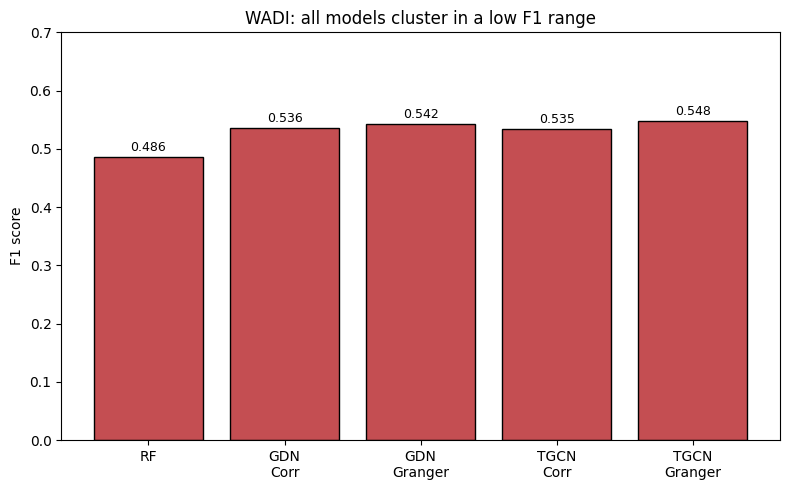

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

configs = ["RF", "GDN\nCorr", "GDN\nGranger", "TGCN\nCorr", "TGCN\nGranger"]
f1_vals = [rf_results["f1"], gdn_corr_results["f1"], gdn_granger_results["f1"],
           tgcn_corr_results["f1"], tgcn_granger_results["f1"]]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(configs, f1_vals, color="#C44E52", edgecolor="black")
for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.3f}", ha="center", fontsize=9)
ax.set_ylabel("F1 score")
ax.set_ylim(0, 0.7)
ax.set_title("WADI: all models cluster in a low F1 range")
plt.tight_layout()
plt.savefig("fig4_8_wadi_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()